# Filtraggio Dataset Lunare — v4 (Interactive)

Versione interattiva. Re-esegui qualsiasi cella di visualizzazione per ottenere nuovi campioni casuali.

**Categorizzazione finale (v4):**

| Categoria | Significato | Tenere? |
|---|---|---|
| `mask_all_white` | maschera completamente 1 | ❌ scartare |
| `mask_block` | grosso blocco bianco contiguo nella maschera | ❌ scartare |
| `mask_stripe` | bande orizzontali nella maschera | ❌ scartare |
| `image_lowcontrast` | immagine quasi uniforme (acquisizione assente) | ❌ scartare |
| `normale` | tutto il resto — include foto scure, banding sensoriale, **disallineamenti** (recuperabili via rotazione) | ✅ tenere |

## 1. Setup

In [1]:
%matplotlib inline

from __future__ import annotations

import os
import warnings
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import label
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# Path (relativi alla cartella notebooks/)
DATA_DIR    = '../lunar_segmentation/data/MR'
INDEX_PATH  = os.path.join(DATA_DIR, 'tiles', 'index.csv')
REPORT_PATH = os.path.join(DATA_DIR, 'tiles', 'corruption_report_v4.csv')
CLEAN_PATH  = os.path.join(DATA_DIR, 'tiles', 'index_clean_v4.csv')

# Soglie (modifica e ri-esegui l'analisi con force=True)
SOGLIE = {
    'mask_block_frac': 0.40,
    'mask_stripe_white_rows': 5,
    'mask_stripe_transitions': 2,
    'image_lowcontrast_std': 0.03,
}

CATEGORIE = [
    'mask_all_white',
    'mask_block',
    'mask_stripe',
    'image_lowcontrast',
    'normale',
    'errore',
]

COLOR_MAP = {
    'mask_all_white':    '#e74c3c',
    'mask_block':        '#c0392b',
    'mask_stripe':       '#f39c12',
    'image_lowcontrast': '#9b59b6',
    'normale':           '#2ecc71',
    'errore':            '#95a5a6',
}

# Stile dark coerente col notebook originale
plt.rcParams['figure.facecolor'] = '#1a1a2e'
plt.rcParams['axes.facecolor']   = '#16213e'
plt.rcParams['text.color']       = '#e0e0e0'
plt.rcParams['axes.labelcolor']  = '#e0e0e0'
plt.rcParams['xtick.color']      = '#a0a0a0'
plt.rcParams['ytick.color']      = '#a0a0a0'
plt.rcParams['figure.dpi']       = 100

## 2. Funzione di analisi

Restituisce un `TileReport` con tipo + tutti gli score numerici (utili per ispezione e per ri-tarare le soglie).

In [2]:
@dataclass
class TileReport:
    tipo: str = 'normale'
    white_percent: float = 0.0   # % pixel = 1 nella maschera
    n_white_rows: int = 0        # righe della maschera con media = 1.0 (interamente bianche)
    n_transitions: int = 0       # quante volte si passa da blocco bianco a non-bianco (e viceversa)
    max_block_frac: float = 0.0  # frazione area coperta dalla componente connessa più grande nella maschera
    n_craters: int = 0           # numero di componenti connesse (regioni separate di pixel=1) nella maschera (proxy per la stima con scipy.ndimage.label)
    img_std: float = 0.0         # deviazione standard dell'immagine normalizzata (canale 0)
    dark_frac: float = 0.0       # frazione di pixel < 0.02 (quasi neri)
    align_score: float = float('nan')  # rapporto edge Sobel dentro/fuori maschera (vedi sotto)


def _mask_block_frac(mask):
    """
    Trova la componente connessa più grande nella maschera binaria e restituisce
    la sua area come frazione del totale (256*256).
    
    Usato per il check mask_block: se la comp. più grande copre > 40% della tile,
    c'è un grosso blocco bianco contiguo — tipicamente una banda di pixel=1 che
    copre metà maschera con una sola transizione (sfugge al check mask_stripe).
    Soglia: SOGLIE['mask_block_frac'] = 0.40
    """
    labeled, n = label(mask)
    if n == 0:
        return 0.0
    sizes = np.bincount(labeled.ravel())[1:]  # escludi label 0 = sfondo
    return float(sizes.max()) / mask.size


def _align_score(sobel, mask):
    """
    Misura quanto i bordi visibili nell'immagine corrispondono alla maschera.

    Come funziona:
      - image[2] è il canale Sobel pre-calcolato: ogni pixel contiene il modulo
        del gradiente dell'immagine. Valori alti = bordi, transizioni nette.
      - I rim dei crateri sono i bordi più forti dell'immagine lunare.
      - In una tile BEN ALLINEATA: i crateri visibili nell'immagine coincidono
        con le regioni mask==1. I bordi (Sobel alto) si trovano al confine delle
        regioni mascherate → la media del Sobel DENTRO la maschera è più alta
        di quella fuori.
      - In una tile DISALLINEATA (immagine ruotata rispetto alla maschera):
        i bordi dell'immagine non hanno relazione con dove dice la maschera.
        La media dentro e fuori tende a equalizzarsi → rapporto ≈ 1.0.

    Score = mean(Sobel dentro mask==1) / mean(Sobel fuori mask==1)
      > 1.15  → bordi concentrati nella zona mascherata → buon allineamento
      < 1.15  → bordi distribuiti casualmente rispetto alla maschera → sospetto
               disallineamento (recuperabile via rotazione/registrazione)

    Nota: il check viene saltato se la maschera è quasi vuota o quasi piena
    (n_craters < 3 o > 500) perché il rapporto è instabile su maschere estreme.
    Nella v4 questo score è SOLO informativo — non scarta nessuna tile.
    """
    inside  = sobel[mask == 1]
    outside = sobel[mask == 0]
    if inside.size == 0 or outside.size == 0:
        return float('nan')
    eo = float(outside.mean())
    if eo <= 1e-6:
        return float('nan')
    return float(inside.mean()) / eo


def analizza_tile_v4(tile_path):
    r = TileReport()
    try:
        data  = np.load(os.path.join(DATA_DIR, tile_path))
        image = data['image']   # shape (3, 256, 256)
        mask  = data['mask'][0] # canale 0 = crateri d'impatto (valori 0/1)
        img0  = image[0]        # canale normalizzato (brightness)
        sobel = image[2]        # canale Sobel (modulo del gradiente)

        r.white_percent = float(mask.mean() * 100)

        # --- CHECK 1: Maschera tutta bianca ---
        # np.all(mask==1) è più veloce di mean()==100 e non ha errori float
        if np.all(mask == 1):
            r.tipo = 'mask_all_white'
            r.max_block_frac = 1.0
            return r

        # --- CHECK 2: Blocco bianco contiguo grande ---
        # Cerca la componente connessa più grande. Se > 40% della tile,
        # la maschera ha un grosso blocco bianco compatto (es. la metà superiore
        # tutta=1 e la metà inferiore normale). Con una sola transizione sfugge
        # al check mask_stripe, quindi serve questo check separato.
        r.max_block_frac = _mask_block_frac(mask)
        if r.max_block_frac > SOGLIE['mask_block_frac']:  # default 0.40
            r.tipo = 'mask_block'
            r.n_craters = int(label(mask)[1])
            return r

        # --- CHECK 3: Stripe orizzontali nella maschera ---
        # Calcola la media di ogni riga. Se la media == 1.0, la riga è tutta bianca.
        # Le "transizioni" contano quante volte si passa da riga-bianca a riga-normale
        # e viceversa. In una maschera reale le righe bianche (se ci sono) sono contigue
        # → 0 transizioni. In una stripe corrotta ci sono blocchi alternati → ≥ 2 trans.
        row_means = mask.mean(axis=1)
        is_white  = (row_means == 1.0)
        r.n_white_rows  = int(is_white.sum())
        r.n_transitions = int(np.abs(np.diff(is_white.astype(int))).sum())
        if (r.n_white_rows > SOGLIE['mask_stripe_white_rows']   # default 5
                and r.n_transitions >= SOGLIE['mask_stripe_transitions']):  # default 2
            r.tipo = 'mask_stripe'
            r.n_craters = int(label(mask)[1])
            return r

        # --- CHECK 4: Immagine senza contrasto ---
        # std globale < 0.03 su immagine in [0,1] = quasi uniforme.
        # Tipicamente indica dati mancanti o acquisizione fallita.
        r.img_std   = float(img0.std())
        r.dark_frac = float((img0 < 0.02).mean())

        # n_craters: componenti connesse separate nella maschera.
        # NON è un metadato dell'index.csv (che ha solo positive_pixels = pixel totali=1).
        # Viene calcolato qui tramite scipy.ndimage.label che etichetta regioni connesse.
        # Ogni "isola" di pixel=1 separata dagli altri conta come un cratere.
        r.n_craters = int(label(mask)[1])

        if r.img_std < SOGLIE['image_lowcontrast_std']:  # default 0.03
            r.tipo = 'image_lowcontrast'
            return r

        # Score informativo: NON filtra. Tutte le tile arrivate qui
        # sono 'normale' indipendentemente dall'align_score.
        r.align_score = _align_score(sobel, mask)
        r.tipo = 'normale'
        return r

    except Exception:
        r.tipo = 'errore'
        return r

## 3. Esecuzione su tutto il dataset

Prima esecuzione: ~1 minuto. Le esecuzioni successive caricano dal CSV di cache (forza il ricalcolo con `force=True`).

In [3]:
def analizza_dataset(df):
    rows = [asdict(analizza_tile_v4(p)) for p in tqdm(df['tile_path'], desc='Analisi tile')]
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(rows)], axis=1)

def carica_o_analizza(force=False):
    if (not force) and os.path.exists(REPORT_PATH):
        print(f'Carico cache: {REPORT_PATH}')
        return pd.read_csv(REPORT_PATH)
    print(f'Eseguo analisi su {INDEX_PATH}')
    df_in = pd.read_csv(INDEX_PATH)
    print(f'  Tile totali: {len(df_in)}')
    out = analizza_dataset(df_in)
    out.to_csv(REPORT_PATH, index=False)
    out[out['tipo'] == 'normale'].to_csv(CLEAN_PATH, index=False)
    print(f'Salvati: {REPORT_PATH} e {CLEAN_PATH}')
    return out

df = carica_o_analizza(force=False)  # metti force=True dopo aver cambiato SOGLIE
df.shape

Carico cache: ../lunar_segmentation/data/MR/tiles/corruption_report_v4.csv


(15931, 14)

In [4]:
# Distribuzione
conteggi = df['tipo'].value_counts()
tot = len(df)
print('=' * 60)
print('  DISTRIBUZIONE v4')
print('=' * 60)
for cat in CATEGORIE:
    if cat in conteggi:
        n = int(conteggi[cat])
        print(f'  {cat:20s}: {n:6d}  ({n/tot*100:5.1f}%)')
print('-' * 60)
print(f'  {"TOTALE":20s}: {tot:6d}')
print('=' * 60)

  DISTRIBUZIONE v4
  mask_all_white      :   7799  ( 49.0%)
  mask_block          :   5017  ( 31.5%)
  mask_stripe         :   2336  ( 14.7%)
  image_lowcontrast   :      2  (  0.0%)
  normale             :    777  (  4.9%)
------------------------------------------------------------
  TOTALE              :  15931


## 4. Visualizzazione per categoria

Re-esegui qualsiasi cella sottostante per vedere **nuovi campioni casuali** (niente seed).

In [5]:
def visualizza_categoria(categoria, n=4):
    """Mostra n esempi casuali della categoria scelta. Re-eseguibile."""
    subset = df[df['tipo'] == categoria]
    if subset.empty:
        print(f"(nessuna tile nella categoria '{categoria}')")
        return
    campioni = subset.sample(min(n, len(subset)))  # senza random_state

    fig, axes = plt.subplots(len(campioni), 2,
                              figsize=(8, 3.2 * len(campioni)))
    if len(campioni) == 1:
        axes = np.array([axes])

    for i, (_, row) in enumerate(campioni.iterrows()):
        try:
            data = np.load(os.path.join(DATA_DIR, row['tile_path']))
            img  = data['image'][0]
            mask = data['mask'][0]
        except Exception as e:
            axes[i, 0].set_title(f'ERR: {e}', fontsize=8, color='red')
            continue

        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title(os.path.basename(row['tile_path']), fontsize=9)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='RdYlGn_r', vmin=0, vmax=1)
        annot = (f"bianco={row['white_percent']:.1f}%  "
                 f"block={row['max_block_frac']:.2f}  "
                 f"std={row['img_std']:.3f}\n"
                 f"dark={row['dark_frac']:.2f}  "
                 f"align={row['align_score']:.2f}  "
                 f"crateri={row['n_craters']}")
        axes[i, 1].set_title(annot, fontsize=8)
        axes[i, 1].axis('off')

    fig.suptitle(f"Categoria: {categoria}  ({len(subset)} tile in totale)",
                 fontsize=12, fontweight='bold',
                 color=COLOR_MAP.get(categoria, 'white'))
    plt.tight_layout()
    plt.show()

### ❌ `mask_all_white`
Maschera interamente bianca.

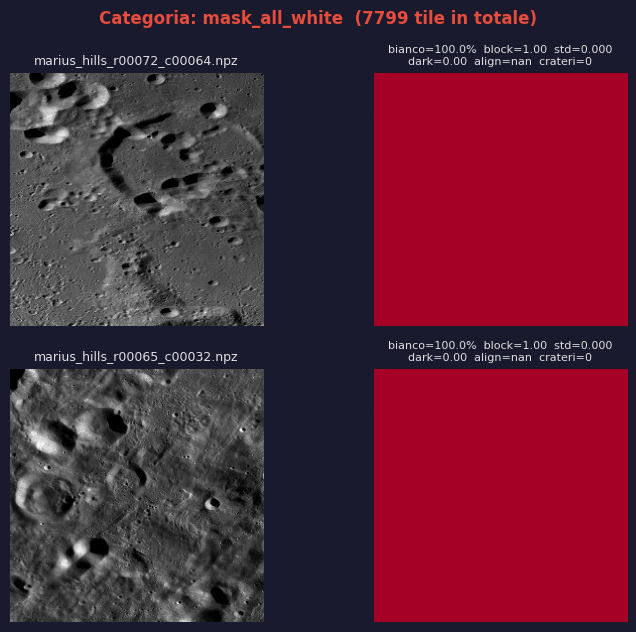

In [6]:
visualizza_categoria('mask_all_white', n=2)

### ❌ `mask_block`
Blocco bianco contiguo che copre > 40% della maschera (singola transizione, non a strisce alternate).

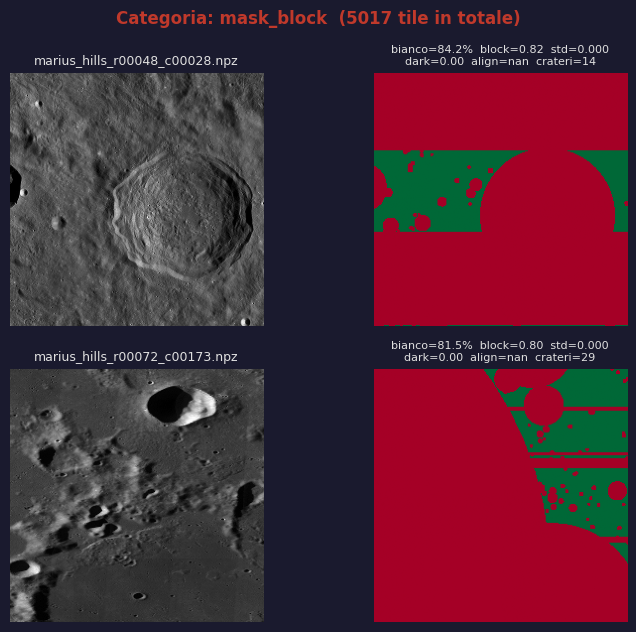

In [7]:
visualizza_categoria('mask_block', n=2)

### ❌ `mask_stripe`
Bande bianche orizzontali alternate.

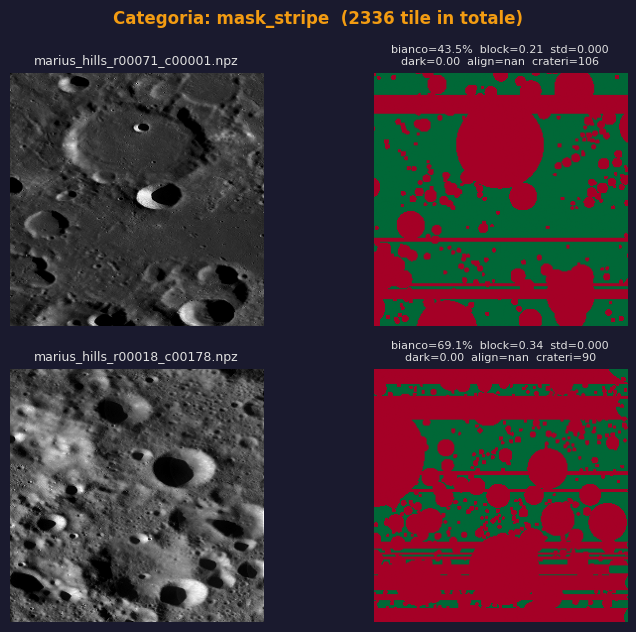

In [8]:
visualizza_categoria('mask_stripe', n=2)

### ❌ `image_lowcontrast`
Immagine quasi uniforme (std < 0.03), acquisizione probabilmente mancante.

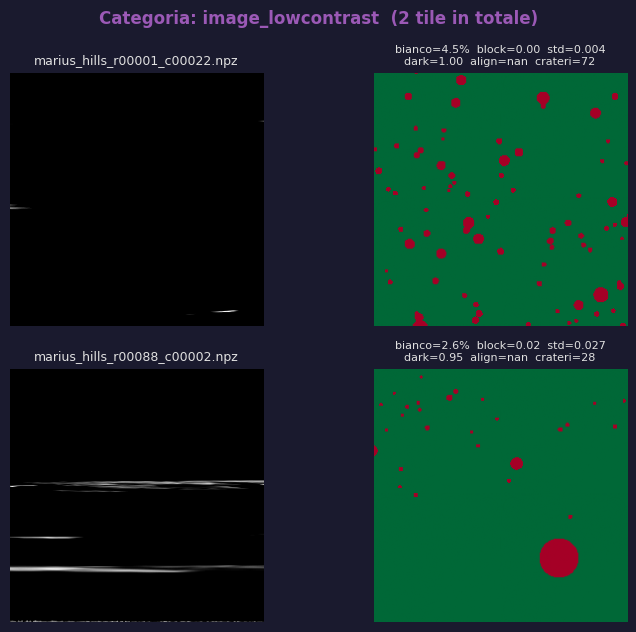

In [9]:
visualizza_categoria('image_lowcontrast', n=4)

### ✅ `normale`
Tutto il resto (incluse foto scure, con banding sensoriale, o disallineate — tutte recuperabili a valle).

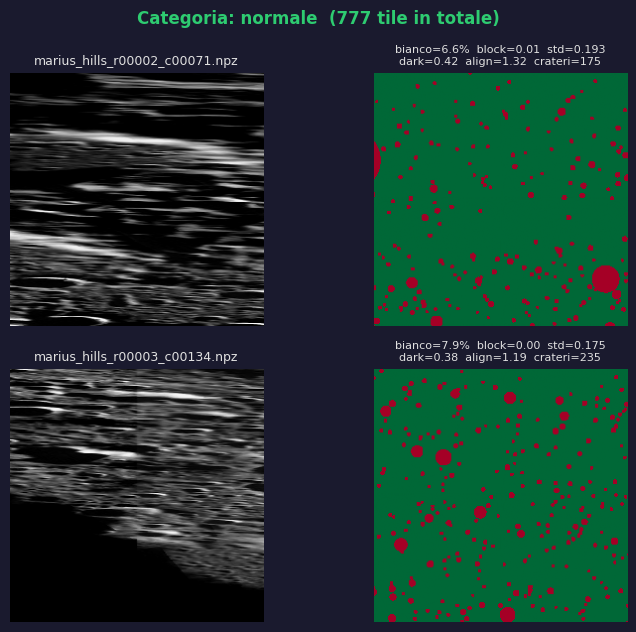

In [10]:
visualizza_categoria('normale', n=2)

## 5. Curator interattivo — selezione manuale delle 777 tile `normale`

Scorri le tile una per una con i tasti. Ogni click salva la decisione su `tiles/curator_decisions.csv`.

**Requisito:** `ipywidgets` installato nell'environment in uso. Se manca, esegui in un cella separata:
```
!pip install ipywidgets
```
e poi **riavvia il kernel**. Il widget riprende automaticamente dall'ultima tile non decisa.

In [13]:
import ipywidgets as widgets
from IPython.display import display

# Path del file con le decisioni — viene aggiornato ad OGNI click
DECISIONS_PATH = os.path.join(DATA_DIR, 'tiles', 'curator_decisions.csv')

# Le tile da curare = tutte le 'normale' del report v4
candidates = df[df['tipo'] == 'normale'].reset_index(drop=True)
N = len(candidates)
print(f'Tile da curare: {N}')

# Carica decisioni precedenti se il file esiste (riprende dove si era)
if os.path.exists(DECISIONS_PATH):
    decisions = pd.read_csv(DECISIONS_PATH).set_index('tile_path')['decision'].to_dict()
    print(f'Caricate {len(decisions)} decisioni esistenti da {DECISIONS_PATH}')
else:
    decisions = {}
    print(f'Nessun file di decisioni — partenza da zero')

# Riparti dalla prima tile non ancora decisa
state = {'idx': 0}
for i, row in candidates.iterrows():
    if row['tile_path'] not in decisions:
        state['idx'] = i
        break

# --- Widget UI ---
out         = widgets.Output()
header      = widgets.HTML()
status      = widgets.HTML()
btn_back    = widgets.Button(description='⬅ Indietro',         layout=widgets.Layout(width='150px'))
btn_drop    = widgets.Button(description='❌ Scarta e avanti', button_style='danger',  layout=widgets.Layout(width='200px'))
btn_keep    = widgets.Button(description='✅ Tieni e avanti',  button_style='success', layout=widgets.Layout(width='200px'))
btn_skip    = widgets.Button(description='⏭ Avanti (no cambio)', layout=widgets.Layout(width='200px'))

def save_decisions():
    """Riscrive l'intero file ad ogni click — per 777 tile è istantaneo."""
    pd.DataFrame([{'tile_path': k, 'decision': v} for k, v in decisions.items()]
                 ).to_csv(DECISIONS_PATH, index=False)

def render():
    idx = state['idx']
    row = candidates.iloc[idx]
    current = decisions.get(row['tile_path'], '—')

    # Plot
    with out:
        out.clear_output(wait=True)
        data = np.load(os.path.join(DATA_DIR, row['tile_path']))
        fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
        axes[0].imshow(data['image'][0], cmap='gray')
        axes[0].set_title(os.path.basename(row['tile_path']), fontsize=10)
        axes[0].axis('off')
        axes[1].imshow(data['mask'][0], cmap='RdYlGn_r', vmin=0, vmax=1)
        axes[1].set_title(f"crateri={row['n_craters']}  align={row['align_score']:.2f}  "
                          f"dark={row['dark_frac']:.2f}  std={row['img_std']:.3f}",
                          fontsize=9)
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()

    # Header + status
    header.value = f"<h3 style='color:#e0e0e0;margin:4px 0'>Tile {idx+1} / {N}</h3>"
    color = {'keep': '#2ecc71', 'discard': '#e74c3c'}.get(current, '#a0a0a0')
    n_keep = sum(1 for v in decisions.values() if v == 'keep')
    n_drop = sum(1 for v in decisions.values() if v == 'discard')
    n_todo = N - n_keep - n_drop
    status.value = (
        f"<div style='color:#e0e0e0;font-family:monospace'>"
        f"Decisione corrente: <b style='color:{color}'>{current}</b><br>"
        f"Totali salvati: "
        f"<span style='color:#2ecc71'>{n_keep} tenute</span> · "
        f"<span style='color:#e74c3c'>{n_drop} scartate</span> · "
        f"<span style='color:#a0a0a0'>{n_todo} da decidere</span><br>"
        f"File: <code>{DECISIONS_PATH}</code>"
        f"</div>"
    )

def go(delta):
    state['idx'] = max(0, min(N - 1, state['idx'] + delta))
    render()

def on_back(_): go(-1)
def on_skip(_): go(+1)
def on_keep(_):
    decisions[candidates.iloc[state['idx']]['tile_path']] = 'keep'
    save_decisions(); go(+1)
def on_drop(_):
    decisions[candidates.iloc[state['idx']]['tile_path']] = 'discard'
    save_decisions(); go(+1)

btn_back.on_click(on_back)
btn_skip.on_click(on_skip)
btn_keep.on_click(on_keep)
btn_drop.on_click(on_drop)

display(
    header,
    out,
    widgets.HBox([btn_back, btn_drop, btn_keep, btn_skip]),
    status,
)
render()

Tile da curare: 777
Nessun file di decisioni — partenza da zero


HTML(value='')

Output()

HTML(value='')

Angolo di imncidenza tra sole luna e veicolo, sono 2 di fatto,

### 🔍 Bonus: tile `normale` con `align_score` basso
Probabili candidate per la futura registrazione/rotazione.

Candidate al recupero (align_score < 1.15): 341 tile


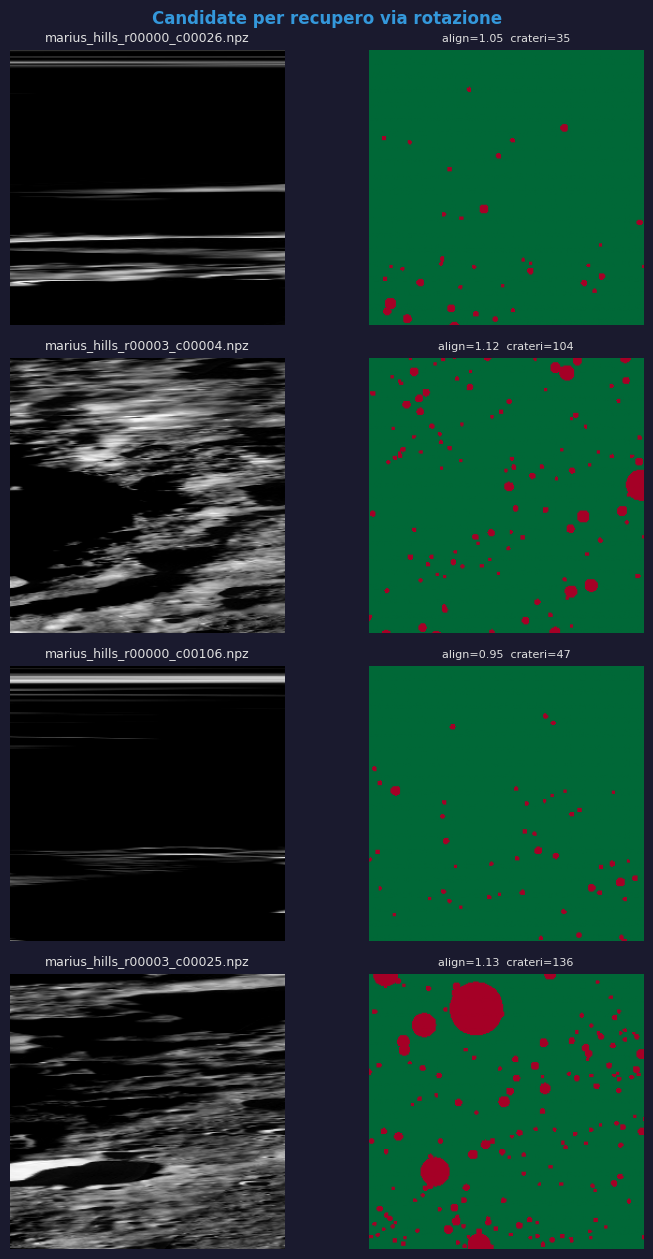

In [12]:
# Filtro estemporaneo: normali con il sospetto di disallineamento
mask = (df['tipo'] == 'normale') & (df['align_score'].notna()) & (df['align_score'] < 1.15)
print(f'Candidate al recupero (align_score < 1.15): {int(mask.sum())} tile')

# Stessa logica di visualizza_categoria ma su filtro custom
subset = df[mask]
if not subset.empty:
    sub = subset.sample(min(4, len(subset)))
    fig, axes = plt.subplots(len(sub), 2, figsize=(8, 3.2 * len(sub)))
    if len(sub) == 1:
        axes = np.array([axes])
    for i, (_, row) in enumerate(sub.iterrows()):
        data = np.load(os.path.join(DATA_DIR, row['tile_path']))
        axes[i, 0].imshow(data['image'][0], cmap='gray')
        axes[i, 0].set_title(os.path.basename(row['tile_path']), fontsize=9)
        axes[i, 0].axis('off')
        axes[i, 1].imshow(data['mask'][0], cmap='RdYlGn_r', vmin=0, vmax=1)
        axes[i, 1].set_title(f"align={row['align_score']:.2f}  crateri={row['n_craters']}", fontsize=8)
        axes[i, 1].axis('off')
    fig.suptitle('Candidate per recupero via rotazione', fontsize=12, fontweight='bold', color='#3498db')
    plt.tight_layout()
    plt.show()